In [3]:
import pysam
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
plasmid_coverage = pd.read_csv('/grid/kinney/home/desmara/PacBioMapping/Jack/bc2011.aligned.lib001.coverage', sep='\t', header=0)
plasmid_coverage = plasmid_coverage.rename(columns={'#CHROM': 'chromosome', '/grid/kinney/home/desmara/PacBioMapping/Jack/bc2011.aligned.lib001.sorted.bam': 'coverage', 'POS': 'Position in plasmid'})
plasmid_coverage

,chromosome,Position in plasmid,coverage
0,library001_ris_sensative_SMN2_2xInner_2xBC,1,6097880
1,library001_ris_sensative_SMN2_2xInner_2xBC,2,6099234
2,library001_ris_sensative_SMN2_2xInner_2xBC,3,6101209
3,library001_ris_sensative_SMN2_2xInner_2xBC,4,6101964
4,library001_ris_sensative_SMN2_2xInner_2xBC,5,6123977
...,...,...,...
4380,library001_ris_sensative_SMN2_2xInner_2xBC,4381,6147413
4381,library001_ris_sensative_SMN2_2xInner_2xBC,4382,6147287
4382,library001_ris_sensative_SMN2_2xInner_2xBC,4383,6146965
4383,library001_ris_sensative_SMN2_2xInner_2xBC,4384,6037640


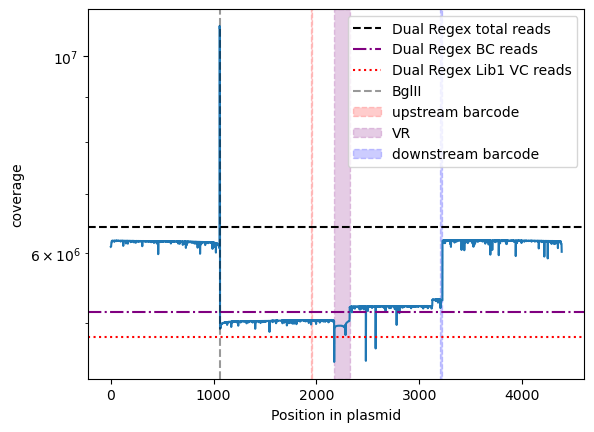

In [17]:
sns.lineplot(x='Position in plasmid', y='coverage', data=plasmid_coverage)
plt.axhline(y=6424942, color='black', linestyle='--', label='Dual Regex total reads')
plt.axhline(y=5142034, color='purple', linestyle='-.', label='Dual Regex BC reads')
plt.axhline(y=4820177, color='red', linestyle=':', label='Dual Regex Lib1 VC reads')

plt.axvline(x=1059, color='k', linestyle='--', alpha=0.4, label='BglII')
plt.axvspan(xmax=1948, xmin=1953, color='red', linestyle='--', alpha=0.2, label='upstream barcode')
plt.axvspan(xmax=2173, xmin=2322, color='purple', linestyle='--', alpha=0.2, label='VR')
plt.axvspan(xmax=3206, xmin=3225, color='blue', linestyle='--', alpha=0.2, label='downstream barcode')
plt.yscale('log')  
plt.legend()
plt.show()


In [7]:
top_cut = 6.5e6
mid_cut = 5.5e6
bottom_cut = 4.5e6


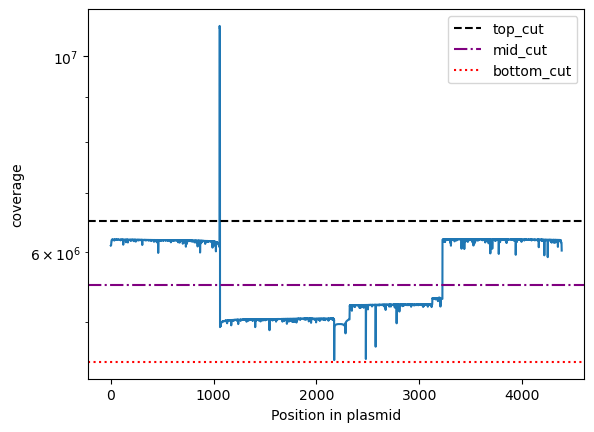

In [8]:
sns.lineplot(x='Position in plasmid', y='coverage', data=plasmid_coverage)
plt.axhline(y=top_cut, color='black', linestyle='--', label='top_cut')
plt.axhline(y=mid_cut, color='purple', linestyle='-.', label='mid_cut')
plt.axhline(y=bottom_cut, color='red', linestyle=':', label='bottom_cut')

plt.yscale('log')  
plt.legend()
plt.show()


In [14]:
bb_average = plasmid_coverage[(plasmid_coverage['coverage']>mid_cut)&(plasmid_coverage['coverage']<top_cut)]['coverage'].mean()
bb_average

np.float64(6186754.541027953)

In [13]:
mini_average = plasmid_coverage[(plasmid_coverage['coverage']>bottom_cut)&(plasmid_coverage['coverage']<mid_cut)]['coverage'].mean()
mini_average

np.float64(5109192.252427184)

In [15]:
mini_average/bb_average

np.float64(0.8258275350258638)

In [19]:
bam_path = "/grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/hifi_reads/m84223_251126_143521_s2.hifi_reads.bc2011.bam"
bamfile = pysam.AlignmentFile(bam_path, "rb", check_sq=False)


In [20]:
lengths = bamfile.lengths
lengths


()

In [21]:
query_lengths = [read.query_length for read in bamfile]
query_lengths

[4389,
 4387,
 7783,
 7848,
 7780,
 7773,
 7771,
 7771,
 7771,
 7771,
 7771,
 7771,
 7771,
 7771,
 7771,
 7770,
 7770,
 7770,
 7768,
 7768,
 7767,
 7764,
 7357,
 2925,
 7760,
 4373,
 4389,
 4347,
 4388,
 4390,
 4388,
 4363,
 4390,
 4391,
 4389,
 4391,
 4387,
 4393,
 4389,
 3554,
 3555,
 4389,
 4389,
 4372,
 4388,
 4389,
 4387,
 4388,
 4418,
 4389,
 4387,
 4390,
 4383,
 4389,
 4173,
 4389,
 4396,
 4378,
 4357,
 3554,
 3130,
 4382,
 4380,
 4385,
 3506,
 4396,
 4376,
 4382,
 4389,
 4389,
 4386,
 4392,
 4391,
 11777,
 11807,
 11079,
 11804,
 11801,
 11797,
 11787,
 11785,
 11781,
 11430,
 8010,
 7071,
 6014,
 5792,
 5612,
 5135,
 4389,
 4384,
 4388,
 4389,
 4393,
 4366,
 4389,
 4367,
 4378,
 4389,
 4390,
 4389,
 4388,
 4389,
 15128,
 16259,
 24638,
 22904,
 17223,
 11648,
 12583,
 4389,
 4213,
 4215,
 4389,
 4385,
 3261,
 4389,
 4390,
 11626,
 14907,
 6325,
 14895,
 9420,
 8001,
 14874,
 4386,
 4387,
 3561,
 3559,
 4382,
 4399,
 3815,
 4388,
 4388,
 4388,
 4389,
 4386,
 4389,
 4389,
 4389,

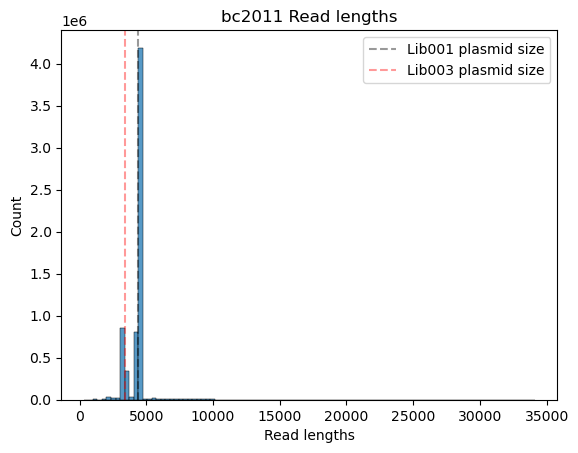

In [26]:
sns.histplot(pd.Series(query_lengths, name='Read lengths'), bins=100)
plt.axvline(x=4385, color='k', linestyle='--', alpha=0.4, label='Lib001 plasmid size')
plt.axvline(x=3408, color='r', linestyle='--', alpha=0.4, label='Lib003 plasmid size')
plt.title('bc2011 Read lengths')
plt.legend()
plt.show()


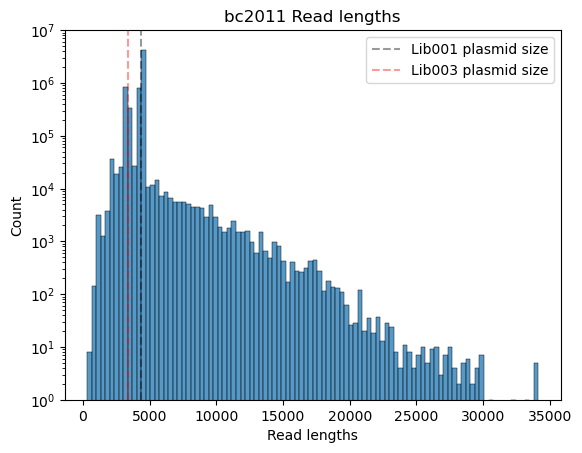

In [29]:
sns.histplot(pd.Series(query_lengths, name='Read lengths'), bins=100)
plt.axvline(x=4385, color='k', linestyle='--', alpha=0.4, label='Lib001 plasmid size')
plt.axvline(x=3408, color='r', linestyle='--', alpha=0.4, label='Lib003 plasmid size')
plt.title('bc2011 Read lengths')
plt.legend()
plt.yscale('log')
plt.ylim(1,1e7)
plt.show()